# Vérification des limites LLM (RPM, TPM, erreurs)

Ce notebook vérifie que les appels vers chaque provider lors du dernier run
respectent les `rpm_limit` définis dans `llm_module/config/providers.yaml`,
et analyse les quotas de tokens, les retries et les erreurs de parsing.

**Sources** : `llm_exchanges.jsonl` (succès) + `llm_errors.jsonl` (erreurs)

> **Note** : le champ `time` enregistre la fin de l'appel (réponse reçue), pas son début.
> La mesure est donc une approximation conservative du RPM/TPM réel.

In [7]:
# Parameters
LOG_DIR     = '../../experiments/2026-05-27_15_43/'
CONFIG_PATH = '../../llm_module/config/providers.yaml'

In [8]:
import json
import os
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml


def load_jsonl(path):
    """Charge un fichier de JSON objets concaténés (format multi-lignes ou NDJSON)."""
    if not os.path.exists(path):
        return pd.DataFrame()
    with open(path) as f:
        content = f.read()
    if not content.strip():
        return pd.DataFrame()
    decoder = json.JSONDecoder()
    records, pos = [], 0
    while pos < len(content):
        try:
            obj, end = decoder.raw_decode(content, pos)
            records.append(obj)
            pos = end
            while pos < len(content) and content[pos] in ' \n\t\r':
                pos += 1
        except json.JSONDecodeError:
            break
    df = pd.DataFrame(records)
    if not df.empty and 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
    return df


def _img_path(title, ext='png'):
    name = ''.join(c if c.isalnum() or c in '-_' else '_' for c in title)
    img_dir = os.path.join(LOG_DIR, 'images/rpm_compliance')
    os.makedirs(img_dir, exist_ok=True)
    return os.path.join(img_dir, f'{name}.{ext}')


# ── Chargement ────────────────────────────────────────────────────────────────
df_success = load_jsonl(os.path.join(LOG_DIR, 'llm_exchanges.jsonl'))
df_error   = load_jsonl(os.path.join(LOG_DIR, 'llm_errors.jsonl'))

with open(CONFIG_PATH) as f:
    providers_cfg = yaml.safe_load(f)['providers']

rpm_limits = {name: cfg['rpm_limit'] for name, cfg in providers_cfg.items()}

print(f'Succès : {len(df_success)} | Erreurs : {len(df_error)}')

if df_success.empty and df_error.empty:
    raise SystemExit('Aucun appel LLM trouvé dans ce run.')

# Combiner succès et erreurs
frames = []
if not df_success.empty:
    df_s = df_success[['time', 'provider']].copy(); df_s['status'] = 'success'
    frames.append(df_s)
if not df_error.empty:
    df_e = df_error[['time', 'provider']].copy(); df_e['status'] = 'error'
    frames.append(df_e)

df_all = pd.concat(frames, ignore_index=True)
df_all['minute'] = df_all['time'].dt.floor('min')

total_per_min = df_all.groupby(['provider', 'minute']).size().rename('total')
max_rpm_obs   = total_per_min.groupby('provider').max().rename('max_rpm_observé')

BAR_W = 0.0006

print(f'Providers actifs : {sorted(df_all["provider"].unique())}')

Succès : 179 | Erreurs : 92
Providers actifs : ['cerebras_gpt-oss-120b', 'cerebras_llama31_8b', 'cerebras_qwen3', 'google_gemini31', 'google_gemma42', 'google_gemma43', 'groq_llama3', 'groq_llama31', 'groq_llama4', 'groq_openai_120', 'groq_openai_20', 'groq_qwen', 'mistral']


## 1 · Tableau de conformité RPM

In [9]:
rows = []
for prov in sorted(df_all['provider'].unique()):
    limit    = rpm_limits.get(prov)
    observed = int(max_rpm_obs.get(prov, 0))
    if limit is None:
        status = '⚠ limite inconnue'
    elif observed <= limit:
        status = '✓ conforme'
    else:
        status = f'✗ dépassement (+{observed - limit})'
    rows.append({'provider': prov, 'rpm_limit': limit, 'max_rpm_observé': observed, 'statut': status})

compliance = pd.DataFrame(rows).set_index('provider')
compliance

,rpm_limit,max_rpm_observé,statut
provider,,,
cerebras_gpt-oss-120b,5,3,✓ conforme
cerebras_llama31_8b,5,3,✓ conforme
cerebras_qwen3,5,3,✓ conforme
google_gemini31,15,8,✓ conforme
google_gemma42,5,2,✓ conforme
google_gemma43,15,4,✓ conforme
groq_llama3,25,5,✓ conforme
groq_llama31,10,3,✓ conforme
groq_llama4,25,5,✓ conforme


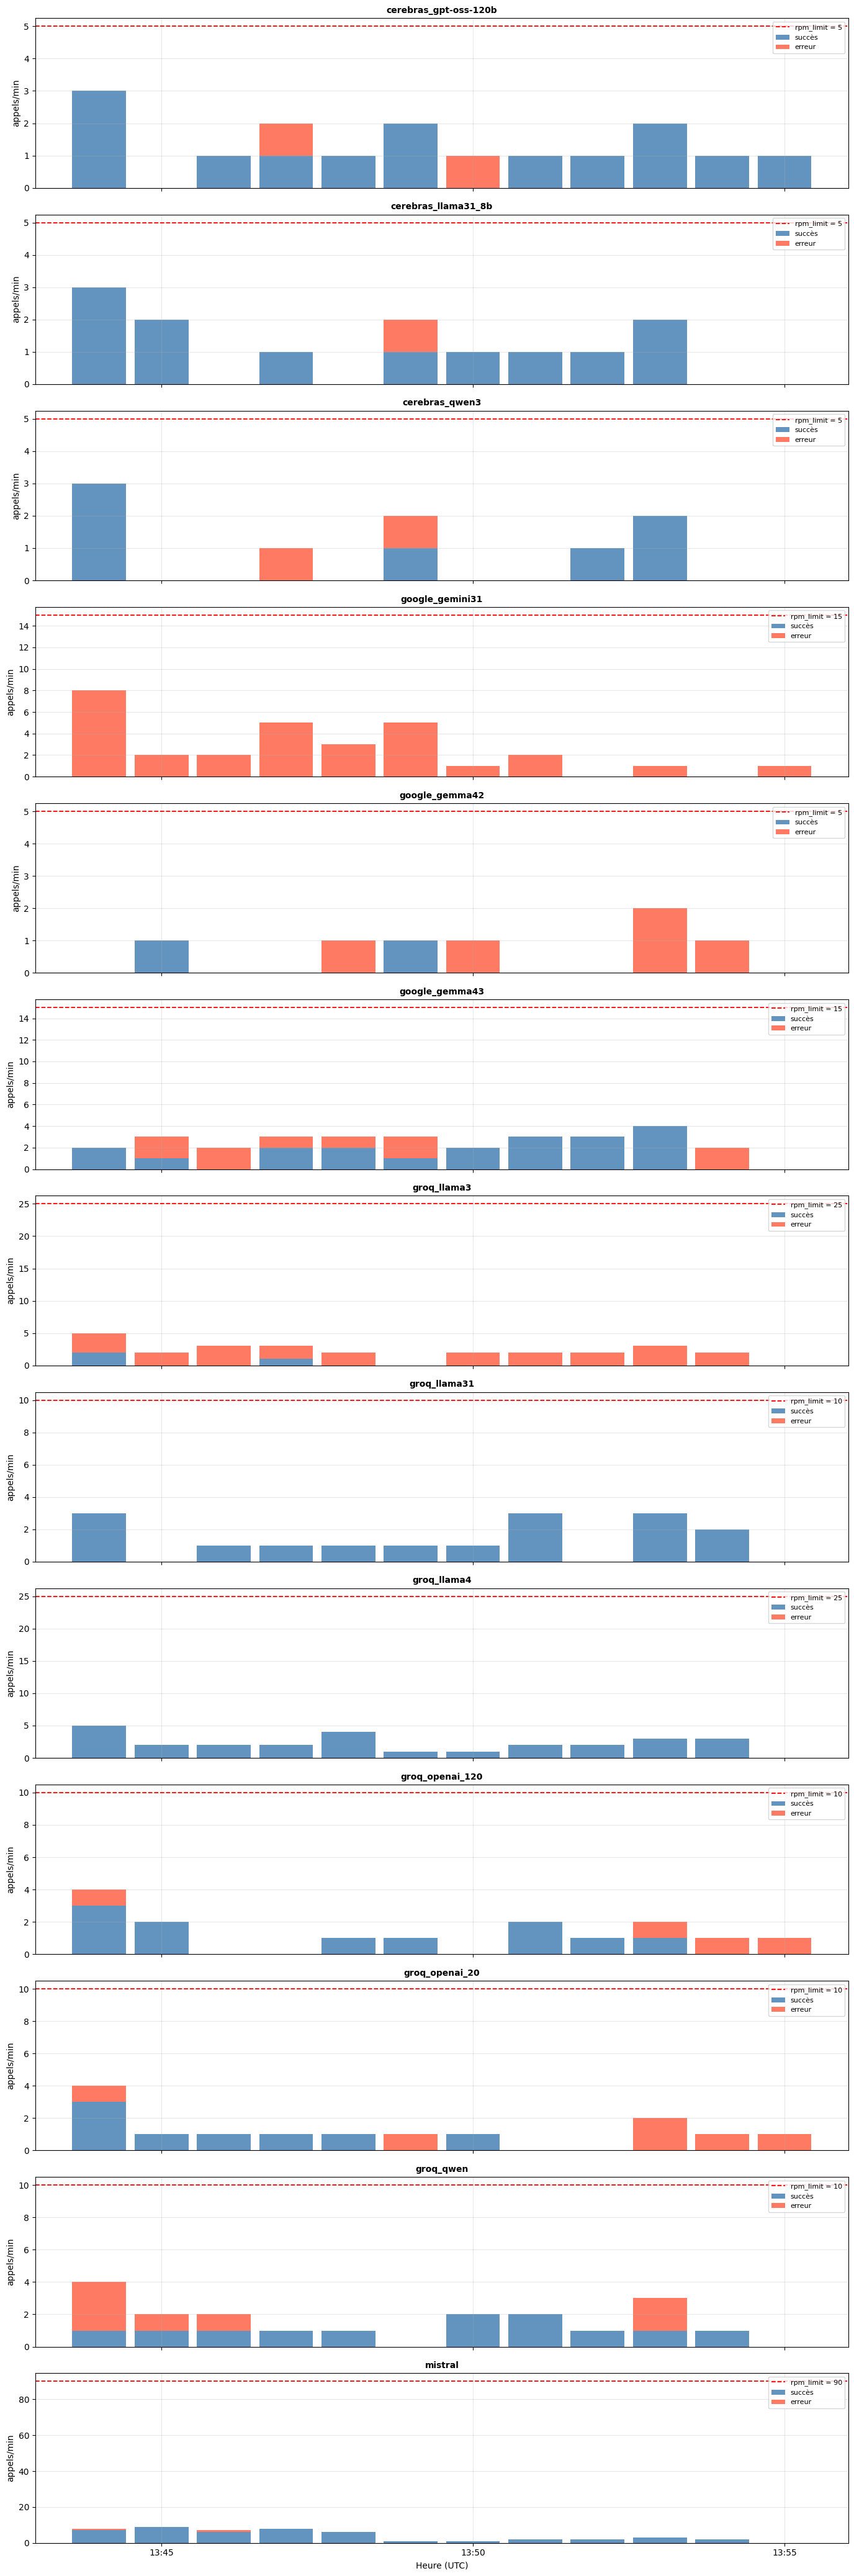

Aucune violation RPM détectée.


In [10]:
calls_per_min = (
    df_all.groupby(['provider', 'minute', 'status'])
    .size()
    .unstack('status', fill_value=0)
)

providers_sorted = sorted(df_all['provider'].unique())
n = len(providers_sorted)

fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, prov in zip(axes, providers_sorted):
    rpm_limit = rpm_limits.get(prov)
    if prov in calls_per_min.index.get_level_values('provider'):
        prov_data    = calls_per_min.xs(prov, level='provider')
        success_vals = prov_data.get('success', pd.Series(0, index=prov_data.index))
        error_vals   = prov_data.get('error',   pd.Series(0, index=prov_data.index))
        ax.bar(prov_data.index, success_vals, width=BAR_W, label='succès', color='steelblue', alpha=0.85)
        ax.bar(prov_data.index, error_vals,   width=BAR_W, label='erreur', color='tomato',    alpha=0.85, bottom=success_vals)
    if rpm_limit is not None:
        ax.axhline(rpm_limit, color='red', linestyle='--', linewidth=1.3, label=f'rpm_limit = {rpm_limit}')
    ax.set_title(prov, fontsize=10, fontweight='bold')
    ax.set_ylabel('appels/min')
    ax.legend(fontsize=8, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Heure (UTC)')
plt.tight_layout()
plt.savefig(_img_path('rpm_per_provider'), dpi=150)
plt.show()

violations = [
    {'provider': prov, 'minute': minute.strftime('%H:%M'), 'appels': int(count),
     'rpm_limit': int(rpm_limits[prov]), 'dépassement': int(count - rpm_limits[prov])}
    for (prov, minute), count in total_per_min.items()
    if prov in rpm_limits and count > rpm_limits[prov]
]
if violations:
    print(f'{len(violations)} violation(s) :')
    display(pd.DataFrame(violations).sort_values('dépassement', ascending=False))
else:
    print('Aucune violation RPM détectée.')

## 2 · TPM observé et limites extraites des erreurs 429

Les messages d'erreur Groq contiennent `Limit X, Used Y, Requested Z` pour TPM et TPD.
On reconstruit ici le TPM observé (tokens traités par minute) et on le compare aux limites déclarées par le provider.

In [11]:
# ── Extraction des quotas depuis les messages 429 ──────────────────────────────
_QUOTA_RE = re.compile(
    r'on (tokens per \w+) \((\w+)\): Limit ([\d,]+), Used ([\d,]+), Requested ([\d,]+)'
    r'.*?try again in ([^"\n]+)',
    re.IGNORECASE
)

def _parse_quota(msg):
    m = _QUOTA_RE.search(str(msg))
    if not m:
        return None
    return {
        'quota_type': m.group(2),          # TPM ou TPD
        'limit':      int(m.group(3).replace(',', '')),
        'used':       int(m.group(4).replace(',', '')),
        'requested':  int(m.group(5).replace(',', '')),
        'retry_in':   m.group(6).strip(),
    }

quota_rows = []
if not df_error.empty and 'http_status' in df_error.columns:
    df_429 = df_error[df_error['http_status'] == 429].copy()
    for _, row in df_429.iterrows():
        parsed = _parse_quota(row.get('error_message', ''))
        if parsed:
            quota_rows.append({'provider': row['provider'], 'time': row['time'], **parsed})

if not quota_rows:
    print('Aucun quota parsé (messages 429 sans détail Limit/Used).')
else:
    df_quota = pd.DataFrame(quota_rows)
    # Taux d'utilisation au moment du refus
    df_quota['pct_used'] = (df_quota['used'] / df_quota['limit'] * 100).round(1)
    df_quota['pct_requested'] = (df_quota['requested'] / df_quota['limit'] * 100).round(1)

    summary_quota = (
        df_quota.groupby(['provider', 'quota_type'])
        .agg(
            nb_refus=('limit', 'count'),
            limit=('limit', 'first'),
            used_max=('used', 'max'),
            requested_mean=('requested', 'mean'),
            pct_used_max=('pct_used', 'max'),
        )
        .reset_index()
        .sort_values(['provider', 'quota_type'])
    )
    summary_quota['requested_mean'] = summary_quota['requested_mean'].round(0).astype(int)
    display(summary_quota)

,provider,quota_type,nb_refus,limit,used_max,requested_mean,pct_used_max
0,groq_llama3,TPD,23,100000,99935,4496,99.9
1,groq_openai_120,TPD,3,200000,198766,1820,99.4
2,groq_openai_120,TPM,1,8000,5519,5383,69.0
3,groq_openai_20,TPD,5,200000,198692,4661,99.3
4,groq_openai_20,TPM,1,8000,4291,5176,53.6
5,groq_qwen,TPM,7,6000,5422,4540,90.4


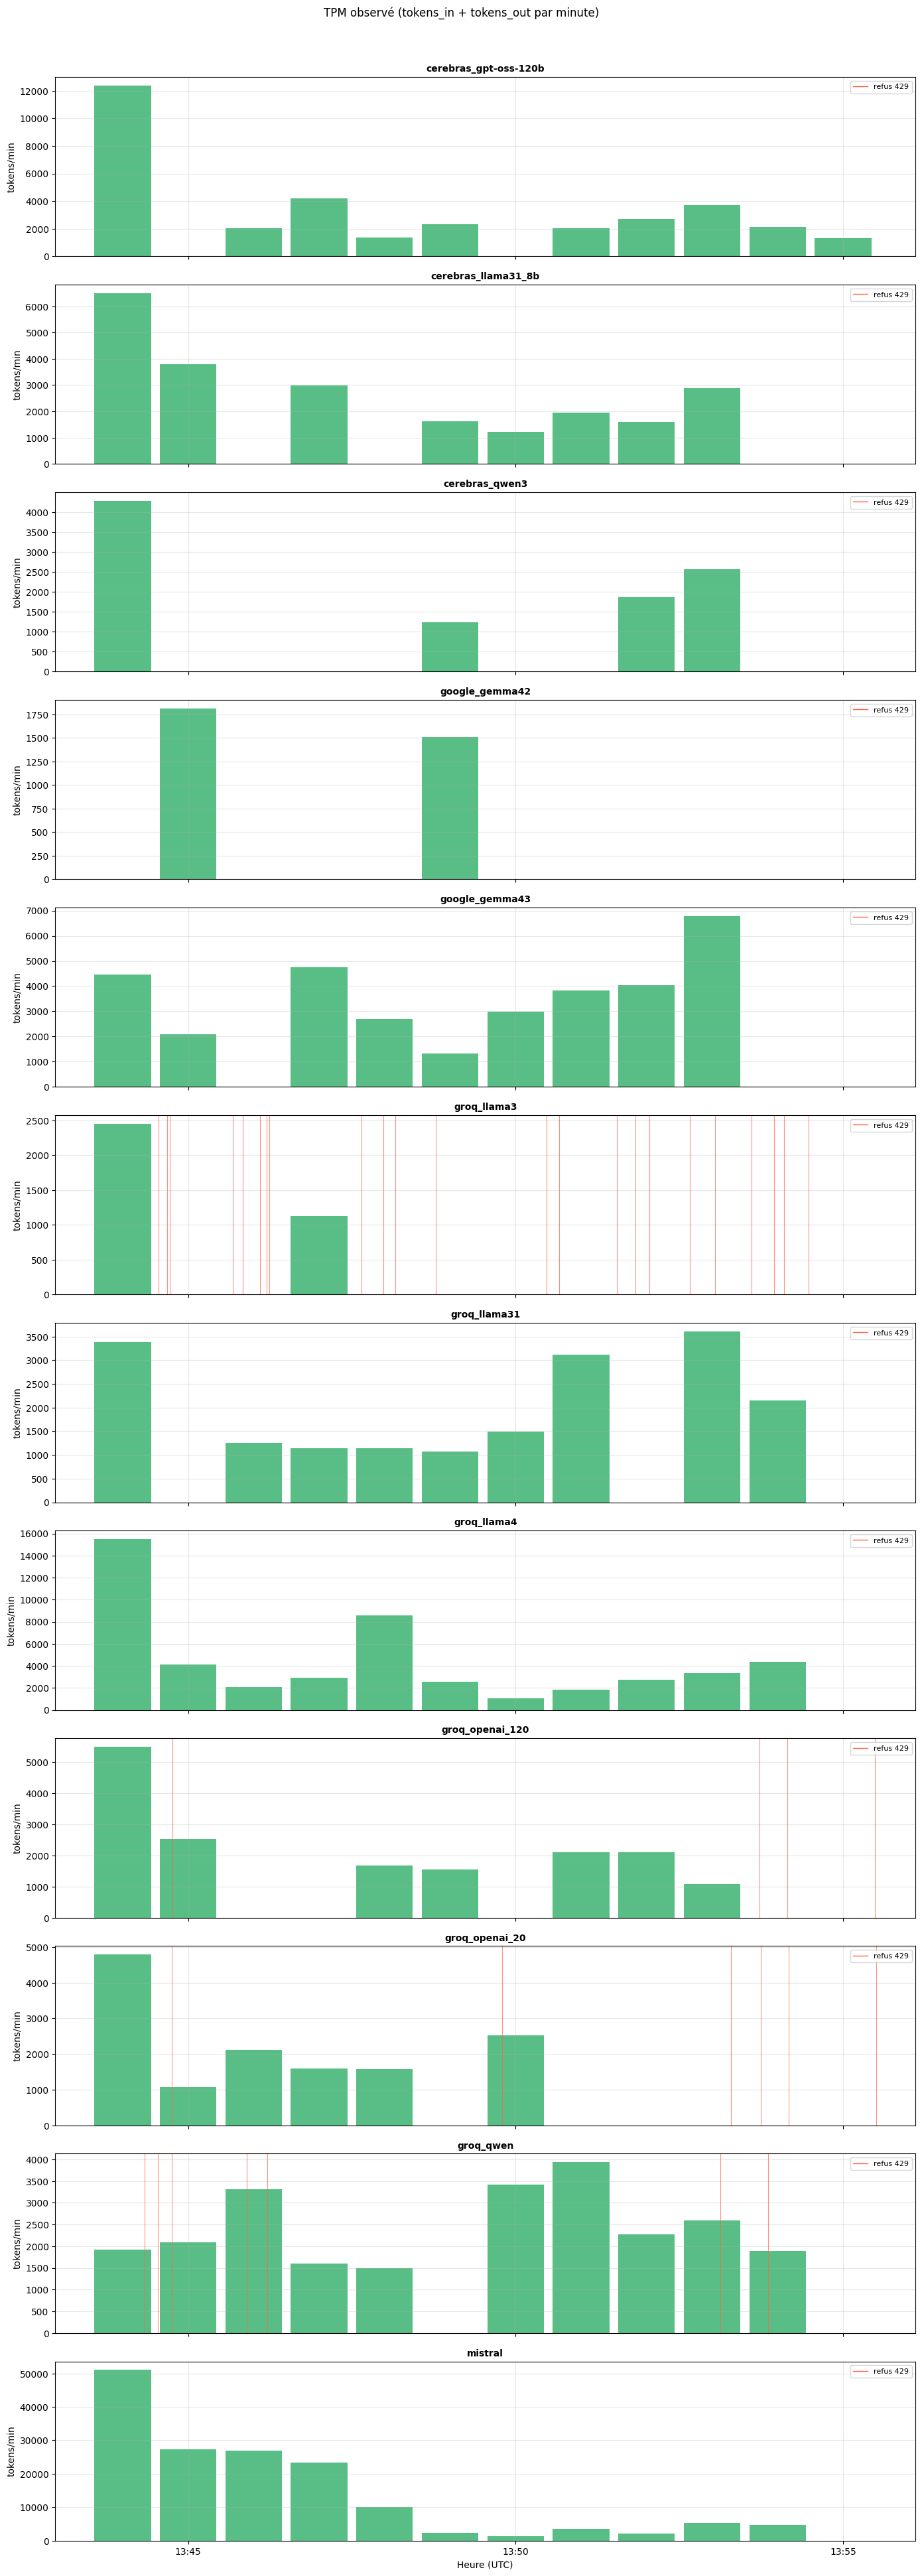

Max TPM observé par provider :


,max_tpm_observé
provider,
cerebras_gpt-oss-120b,12380
cerebras_llama31_8b,6495
cerebras_qwen3,4277
google_gemma42,1811
google_gemma43,6774
groq_llama3,2449
groq_llama31,3604
groq_llama4,15478
groq_openai_120,5495


In [12]:
# ── TPM observé (tokens_in + tokens_out par minute) ────────────────────────────
if not df_success.empty and {'tokens_in', 'tokens_out'}.issubset(df_success.columns):
    df_tok = df_success.copy()
    df_tok['minute']     = df_tok['time'].dt.floor('min')
    df_tok['tokens_tot'] = df_tok['tokens_in'] + df_tok['tokens_out']

    tpm_per_min = df_tok.groupby(['provider', 'minute'])['tokens_tot'].sum()
    max_tpm_obs = tpm_per_min.groupby('provider').max().rename('max_tpm_observé')

    providers_with_tokens = sorted(df_tok['provider'].unique())
    n_t = len(providers_with_tokens)

    fig, axes = plt.subplots(n_t, 1, figsize=(14, 3.2 * n_t), sharex=True)
    if n_t == 1:
        axes = [axes]

    for ax, prov in zip(axes, providers_with_tokens):
        if prov in tpm_per_min.index.get_level_values('provider'):
            tok_data = tpm_per_min.xs(prov, level='provider')
            ax.bar(tok_data.index, tok_data.values, width=BAR_W, color='mediumseagreen', alpha=0.85)

        # Marquer les refus TPM/TPD sur l'axe
        if quota_rows:
            prov_refus = df_quota[(df_quota['provider'] == prov) & (df_quota['quota_type'].isin(['TPM', 'TPD']))]
            for _, r in prov_refus.iterrows():
                ax.axvline(r['time'], color='tomato', linewidth=0.8, alpha=0.7)

        ax.set_title(prov, fontsize=10, fontweight='bold')
        ax.set_ylabel('tokens/min')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.grid(True, alpha=0.3)
        if quota_rows:
            ax.plot([], [], color='tomato', linewidth=1, label='refus 429')
            ax.legend(fontsize=8, loc='upper right')

    axes[-1].set_xlabel('Heure (UTC)')
    plt.suptitle('TPM observé (tokens_in + tokens_out par minute)', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.savefig(_img_path('tpm_per_provider'), dpi=150)
    plt.show()

    print('Max TPM observé par provider :')
    display(max_tpm_obs.to_frame())

## 3 · Timeline des erreurs par catégorie

Chaque erreur est classée en : `429-TPM`, `429-TPD`, `429-RPM`, `404`, `500`, `503/504`, `timeout`, `parse`.

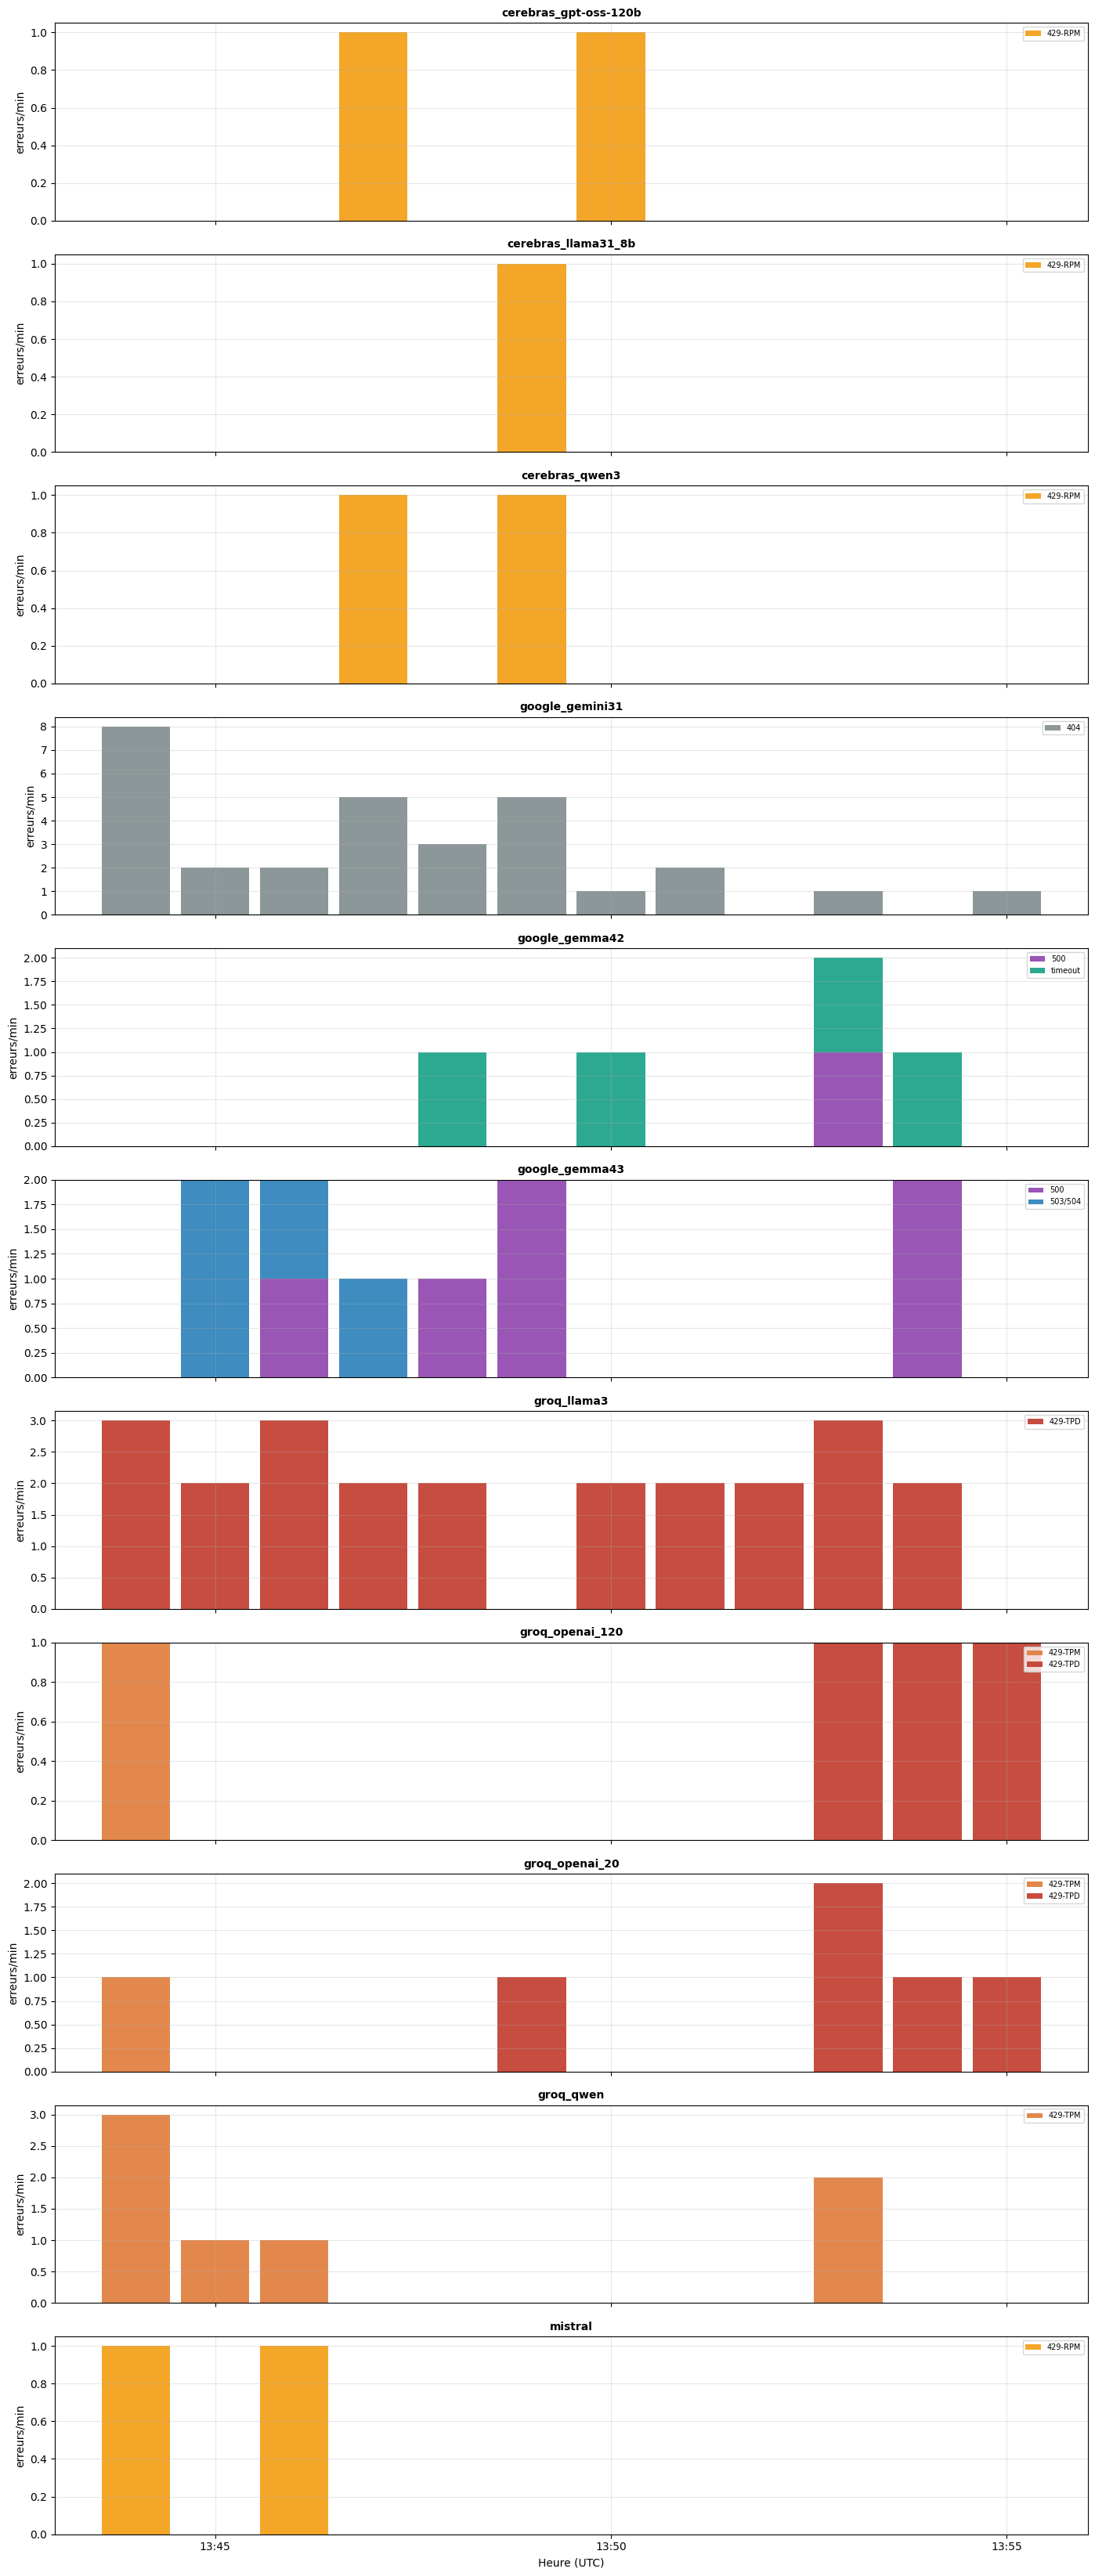

Distribution globale des erreurs par catégorie et provider :


cat,404,429-RPM,429-TPD,429-TPM,500,503/504,timeout
provider,,,,,,,
cerebras_gpt-oss-120b,0,2,0,0,0,0,0
cerebras_llama31_8b,0,1,0,0,0,0,0
cerebras_qwen3,0,2,0,0,0,0,0
google_gemini31,30,0,0,0,0,0,0
google_gemma42,0,0,0,0,1,0,4
google_gemma43,0,0,0,0,6,4,0
groq_llama3,0,0,23,0,0,0,0
groq_openai_120,0,0,3,1,0,0,0
groq_openai_20,0,0,5,1,0,0,0


In [13]:
def _classify_error(row):
    status  = row.get('http_status')
    etype   = str(row.get('error_type', '')).lower()
    emsg    = str(row.get('error_message', '')).lower()
    if etype.startswith('parse error') or 'jsondecode' in etype:
        return 'parse'
    if etype == 'timeout':
        return 'timeout'
    if status == 429:
        if 'tokens per day' in emsg or '(tpd)' in emsg:
            return '429-TPD'
        if 'tokens per minute' in emsg or '(tpm)' in emsg:
            return '429-TPM'
        return '429-RPM'
    if status == 404:
        return '404'
    if status == 500:
        return '500'
    if status in (503, 504):
        return '503/504'
    return 'autre'


CATEGORY_COLORS = {
    '429-TPM':  '#e07b39',
    '429-TPD':  '#c0392b',
    '429-RPM':  '#f39c12',
    '404':      '#7f8c8d',
    '500':      '#8e44ad',
    '503/504':  '#2980b9',
    'timeout':  '#16a085',
    'parse':    '#d35400',
    'autre':    '#bdc3c7',
}

if df_error.empty:
    print('Pas d\'erreurs dans ce run.')
else:
    df_err_c = df_error.copy()
    df_err_c['cat'] = df_err_c.apply(_classify_error, axis=1)
    df_err_c['minute'] = df_err_c['time'].dt.floor('min')

    cats_present = df_err_c['cat'].unique()
    providers_e  = sorted(df_err_c['provider'].unique())
    n_e = len(providers_e)

    fig, axes = plt.subplots(n_e, 1, figsize=(14, 3 * n_e), sharex=True)
    if n_e == 1:
        axes = [axes]

    for ax, prov in zip(axes, providers_e):
        prov_data = df_err_c[df_err_c['provider'] == prov]
        cat_min   = prov_data.groupby(['minute', 'cat']).size().unstack('cat', fill_value=0)
        bottom    = pd.Series(0, index=cat_min.index)
        for cat in [c for c in CATEGORY_COLORS if c in cat_min.columns]:
            ax.bar(cat_min.index, cat_min[cat], bottom=bottom,
                   width=BAR_W, label=cat, color=CATEGORY_COLORS[cat], alpha=0.9)
            bottom = bottom + cat_min[cat]
        ax.set_title(prov, fontsize=10, fontweight='bold')
        ax.set_ylabel('erreurs/min')
        ax.legend(fontsize=7, loc='upper right')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Heure (UTC)')
    plt.tight_layout()
    plt.savefig(_img_path('error_timeline'), dpi=150)
    plt.show()

    print('Distribution globale des erreurs par catégorie et provider :')
    display(
        df_err_c.groupby(['provider', 'cat'])
        .size()
        .unstack('cat', fill_value=0)
        .sort_index()
    )

## 4 · Taux de retry implicite

Un `task_id` présent à la fois dans les erreurs et dans les succès indique une tâche
retentée avec succès. On mesure ici le taux de récupération et le délai moyen par provider.

task_id uniques en erreur  : 80
task_id uniques en succès  : 179
task_id retentés avec succès : 27 (33.8% des erreurs récupérées)


,tâches_récupérées,échecs_totaux,délai_médian_s,délai_max_s
provider,,,,
groq_llama3,12,12,1.375,6.72
groq_qwen,6,8,0.595,1.71
groq_openai_120,3,6,1.710,3.64
groq_openai_20,2,2,1.445,1.49
cerebras_gpt-oss-120b,1,1,0.950,0.95
google_gemma42,1,1,8.110,8.11
google_gemma43,1,1,1.490,1.49
mistral,1,1,0.550,0.55


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_7794/3013814102.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


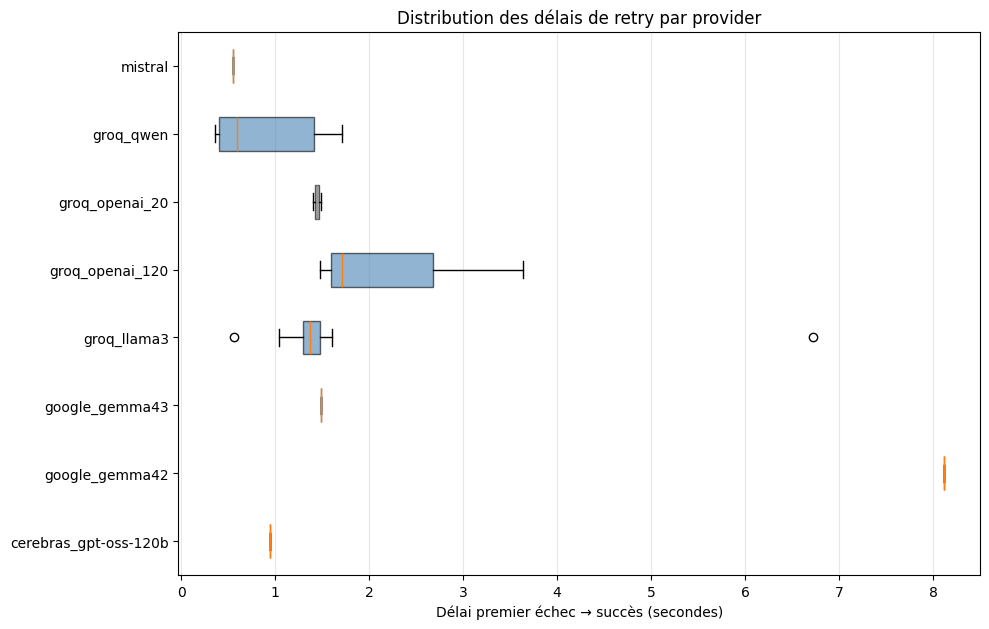

In [14]:
if df_success.empty or df_error.empty or 'task_id' not in df_success.columns or 'task_id' not in df_error.columns:
    print('Données insuffisantes pour analyser les retries.')
else:
    success_ids = set(df_success['task_id'])
    error_ids   = set(df_error['task_id'])
    retried_ids = success_ids & error_ids

    print(f'task_id uniques en erreur  : {len(error_ids)}')
    print(f'task_id uniques en succès  : {len(success_ids)}')
    print(f'task_id retentés avec succès : {len(retried_ids)} '
          f'({len(retried_ids)/len(error_ids)*100:.1f}% des erreurs récupérées)')

    # Délai premier-échec → premier-succès par task_id
    retry_rows = []
    for tid in retried_ids:
        first_err  = df_error[df_error['task_id'] == tid]['time'].min()
        first_succ = df_success[df_success['task_id'] == tid]['time'].min()
        prov_err   = df_error[df_error['task_id'] == tid]['provider'].iloc[0]
        n_attempts = int((df_error['task_id'] == tid).sum())
        delay_s    = (first_succ - first_err).total_seconds()
        retry_rows.append({
            'task_id':    tid,
            'provider':   prov_err,
            'nb_échecs':  n_attempts,
            'délai_s':    round(delay_s, 2),
        })

    df_retry = pd.DataFrame(retry_rows)

    summary_retry = (
        df_retry.groupby('provider')
        .agg(
            tâches_récupérées=('task_id', 'count'),
            échecs_totaux=('nb_échecs', 'sum'),
            délai_médian_s=('délai_s', 'median'),
            délai_max_s=('délai_s', 'max'),
        )
        .sort_values('tâches_récupérées', ascending=False)
    )
    display(summary_retry)

    # Distribution des délais de retry
    provs_retry = sorted(df_retry['provider'].unique())
    fig, ax = plt.subplots(figsize=(10, max(3, len(provs_retry) * 0.8)))
    ax.boxplot(
        [df_retry[df_retry['provider'] == p]['délai_s'].values for p in provs_retry],
        vert=False, labels=provs_retry, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
    )
    ax.set_xlabel('Délai premier échec → succès (secondes)')
    ax.set_title('Distribution des délais de retry par provider')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(_img_path('retry_delays'), dpi=150)
    plt.show()

## 5 · Erreurs de parsing JSON

Les `ProviderParseError` ont un `error_type` commençant par `parse error`.
Ces erreurs indiquent que le LLM a retourné une réponse non conforme au schéma attendu.

In [15]:
if df_error.empty:
    print('Pas d\'erreurs dans ce run.')
else:
    df_parse = df_error[
        df_error['error_type'].str.lower().str.startswith('parse error', na=False) |
        df_error['error_type'].str.lower().str.contains('jsondecode|invalid json|schema', na=False)
    ].copy()

    total_calls = len(df_success) + len(df_error)
    print(f'Erreurs de parsing : {len(df_parse)} / {total_calls} appels total '
          f'({len(df_parse)/total_calls*100:.2f}%)')

    if df_parse.empty:
        print('Aucune erreur de parsing JSON dans ce run — tous les LLMs ont respecté le schéma.')
    else:
        # Taux par provider
        total_by_prov = df_all.groupby('provider').size().rename('total_appels')
        parse_by_prov = df_parse.groupby('provider').size().rename('nb_parse_errors')
        parse_rate    = pd.concat([total_by_prov, parse_by_prov], axis=1).fillna(0)
        parse_rate['nb_parse_errors'] = parse_rate['nb_parse_errors'].astype(int)
        parse_rate['taux_%'] = (parse_rate['nb_parse_errors'] / parse_rate['total_appels'] * 100).round(2)
        parse_rate = parse_rate[parse_rate['nb_parse_errors'] > 0].sort_values('taux_%', ascending=False)
        display(parse_rate)

        # Détail des messages
        cols_show = [c for c in ['time', 'provider', 'task_id', 'error_type', 'error_message'] if c in df_parse.columns]
        pd.set_option('display.max_colwidth', 120)
        display(df_parse[cols_show].sort_values('time').head(20))

        # Timeline
        df_parse['minute'] = df_parse['time'].dt.floor('min')
        parse_timeline     = df_parse.groupby(['provider', 'minute']).size().rename('nb')
        fig, ax = plt.subplots(figsize=(14, 3))
        for prov in parse_timeline.index.get_level_values('provider').unique():
            data = parse_timeline.xs(prov, level='provider')
            ax.bar(data.index, data.values, width=BAR_W, label=prov, alpha=0.85)
        ax.set_title('Erreurs de parsing JSON par minute')
        ax.set_ylabel('erreurs/min')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(_img_path('parse_errors_timeline'), dpi=150)
        plt.show()

Erreurs de parsing : 0 / 271 appels total (0.00%)
Aucune erreur de parsing JSON dans ce run — tous les LLMs ont respecté le schéma.
